## 1. Importing libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("../scripts")
from outlier_utils import print_outliers


## 2. Data Loading 

In [2]:
df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


## 3. Adding column & Date Parsing

In [3]:
# Add country column
df["Country"] = "Ethiopia"

# Convert YEAR + DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


- The dataset encodes dates using Year and Day-of-Year (DOY), which was converted into a proper datetime format to enable time-series analysis and seasonal interpretations.

## 4. Summary Statistics & Missing Values

In [4]:
# Replace sentinel values
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


- No duplicates were found in any of the columns, which means every entry is unique

In [5]:
# Summary statistics
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Brief interpretation of the statistics

### 1. General Overview
- **Time Period**: The data spans from **2015 to 2026** (YEAR min = 2015, max = 2026).
- **Observations**: 4,108 daily records (approximately 11–12 years, accounting for leap years).

---

### 2. Temperature-Related Variables (T2M, T2M_MAX, T2M_MIN, T2M_RANGE)

| Variable | Mean | Min | Max | Interpretation |
|----------|------|-----|-----|----------------|
| **T2M** (mean daily temp) | 16.07°C | 10.03°C | 21.53°C | Generally mild climate; average daily temp varies by ~11.5°C across all years. |
| **T2M_MAX** | 23.20°C | 15.65°C | 30.93°C | Warm days (up to 31°C), but rare extremes above 30°C. |
| **T2M_MIN** | 10.23°C | 1.17°C | 15.68°C | Nights can get cool (down to ~1°C), but never below freezing (min > 0°C). |
| **T2M_RANGE** | 12.97°C | 3.56°C | 23.24°C | Diurnal temperature range is moderate to large. Some days have a ~23°C swing between day and night. |

> No extreme heat or freezing cold. Likely a **temperate or subtropical** climate.

---

### 3. Precipitation (PRECTOTCORR)

| Stat | Value |
|------|-------|
| Mean | 3.63 mm/day |
| Min | 0.00 mm/day |
| Max | 82.30 mm/day |
| 75th percentile | 4.58 mm/day |

- **Most days are dry or get very light rain** (median = 0.82 mm/day, 75% of days ≤ 4.58 mm/day).
- **Rare extreme rainfall events** up to 82 mm/day (likely a heavy storm).
- **Climate type**: Semi-arid to sub-humid. Long dry periods with occasional intense rain.

---

### 4. Humidity & Moisture (RH2M, QV2M)

| Variable | Mean | Range | Interpretation |
|----------|------|-------|----------------|
| **RH2M** (relative humidity) | 68.4% | 14.4% – 91.9% | Generally humid, but can get very dry (14%). |
| **QV2M** (specific humidity) | 9.70 g/kg | 2.12 – 13.52 g/kg | Moderate moisture content; typical of mid-latitude or coastal areas. |

> High RH2M but moderate QV2M suggests **moderate actual water vapor** – not tropical, but not desert-dry either.

---

### 5. Wind (WS2M, WS2M_MAX)

| Variable | Mean | Max | Interpretation |
|----------|------|-----|----------------|
| **WS2M** (mean wind speed) | 1.98 m/s | 4.13 m/s | Generally **light winds** (calm to gentle breeze). |
| **WS2M_MAX** | 3.58 m/s | 7.49 m/s | Peak gusts are modest (up to ~27 km/h) – no extreme wind events. |

> Wind is not a dominant climatic feature here.

---

### 6. Pressure (PS)

- **Mean**: 77.04 kPa
- **Range**: 76.36 – 77.37 kPa

This is **lower than standard sea-level pressure (~101.3 kPa)**.  
> Likely the site is at **moderate to high elevation** (e.g., ~2,000–2,500 m above sea level).

---

### 7. Summary – What kind of climate is this?

| Feature | Inference |
|---------|------------|
| Elevation | Moderate to high (based on PS ~77 kPa) |
| Temperature | Mild, no freezing, rare heat >31°C |
| Rainfall | Mostly dry, occasional heavy downpours |
| Humidity | Moderately humid, can be dry |
| Wind | Light |


> **Likely climate**: **Temperate highland** or **subtropical highland**

## 5. Missing values

In [6]:
# Missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


- there are no null values, which makes our data interpretations and insights we draw from it more accurate since we dont miss anything

## 6. Outlier Detection

In [7]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Calculate z-scores
z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

# Create named DataFrame for easier access
zscore_df = pd.DataFrame(
    z_scores, 
    columns=cols, 
    index=df.index
)

# FLAG the outliers (create a new column)
df['is_outlier'] = (zscore_df > 3).any(axis=1)  # ← THIS IS THE FLAG

# Report the counts
outliers = (z_scores > 3)
outlier_rows = df['is_outlier'].sum()
print("Outlier rows:", outlier_rows)
print(f"Percentage: {df['is_outlier'].mean()*100:.2f}%")

Outlier rows: 132
Percentage: 3.21%


- We have 132 rows with outlier values at one or more column, so now we check if they are erroneous values or seasonal extremities to make a decision whether to keep them or remove them.

### Check outliers by column

In [8]:
# 2. Check outliers by column
print_outliers(zscore_df, cols)

T2M: 3 outliers
T2M_MAX: 0 outliers
T2M_MIN: 18 outliers
PRECTOTCORR: 95 outliers
RH2M: 13 outliers
WS2M: 3 outliers
WS2M_MAX: 5 outliers


### Evaluating outliers

In [9]:
# 1. Physical possibility checks
impossible = df[
    (df["T2M_MAX"] < df["T2M_MIN"]) |  # Max < Min
    (df["RH2M"] > 100) |                # RH > 100%
    (df["RH2M"] < 0) |                  # RH < 0%
    (df["PRECTOTCORR"] < 0)             # Negative rain
]
print(f"Physically impossible rows: {len(impossible)}")

Physically impossible rows: 0


- We have no physically impossible rows, all values are within plausible ranges.

In [10]:
# 2. Check if outliers are seasonal
rain_outliers = df[zscore_df["PRECTOTCORR"] > 3] 
print("Precipitation outliers by month:")
print(rain_outliers["Month"].value_counts().sort_index())

Precipitation outliers by month:
Month
2      1
4      8
5      6
6     11
7     23
8     33
9     10
10     2
11     1
Name: count, dtype: int64


**Total daily precipitation (PRECTOTCORR)**

**Decision**: We will keep the precipitation outliers.

**Reason:**
- **Peak outlier season**: July-August (56% of all Precipitation outliers)
- **Secondary season**: April-June (25% of outliers)
- **Dry season**: November-February (almost none)

> This shows it has a **monsoon or bimodal rainfall pattern** which is very common in tropical highland climates so there is no reason to remove them because they represent real extreme weather removing them would bias the analysis.

In [11]:
min_temp_outliers = df[zscore_df["T2M_MIN"] > 3]
print("Minimun temprature outliers by month:")
print(min_temp_outliers["Month"].value_counts().sort_index())

temp_outliers = df[zscore_df["T2M"] > 3]
print("Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

Minimun temprature outliers by month:
Month
1     7
11    2
12    9
Name: count, dtype: int64
Temprature outliers by month:
Month
11    1
12    2
Name: count, dtype: int64


**Decision**: We will keep the temperature outliers.

**Minimum Temperature Outliers (T2M_MIN)**
**Distribution:** January (7), November (2), December (9)

**Reason:** 
> Cold temperature outliers occur exclusively during the dry season (November-January), when nighttime temperatures naturally reach their annual minimum due to clear skies and lower solar radiation. Values represent real seasonal extremes, not data errors. Removing them would misrepresent normal climate variability.

**Mean Temperature Outliers (T2M)**
**Distribution:** November (1), December (2)

**Reason:**
> Mean temperature outliers coincide with the same dry season period as minimum temperature extremes. These represent legitimate cold spells typical of tropical highland climate during the cool, dry months. Values are physically plausible and seasonally consistent.

In [12]:
relative_humidity_outliers = df[zscore_df["RH2M"] > 3]
print("Relative humidity outliers by month:")
print(relative_humidity_outliers["Month"].value_counts().sort_index())

Relative humidity outliers by month:
Month
1    3
2    1
3    5
4    4
Name: count, dtype: int64


**Decision**: We will keep the humidity outliers.

**Relative Humidity Outliers (RH2M)**
**Distribution:** January (3), February (1), March (5), April (4)

**Reason:**
> Low humidity outliers cluster in Ethiopia's dry and pre-rainy seasons (January-April), when the region experiences maximum solar radiation and minimal rainfall. These extremely dry conditions (RH as low as 23.6%) are physically plausible and represent real drought stress periods that impact agriculture and water resources.

In [13]:
mean_daily_wind_speed_outliers = df[zscore_df["WS2M"] > 3]
print("Mean daily wind speed outliers outliers by month:")
print(mean_daily_wind_speed_outliers["Month"].value_counts().sort_index())

max_daily_wind_speed_outliers = df[zscore_df["WS2M_MAX"] > 3]
print("Max daily wind speed outliers outliers by month:")
print(max_daily_wind_speed_outliers["Month"].value_counts().sort_index())

Mean daily wind speed outliers outliers by month:
Month
1    1
2    2
Name: count, dtype: int64
Max daily wind speed outliers outliers by month:
Month
1     1
3     1
5     2
12    1
Name: count, dtype: int64


**Decision**: We will keep the wind speed outliers.

**Mean Daily Wind Speed Outliers (WS2M)**
**Distribution:** January (1), February (2)

**Reason:**
> Elevated wind speeds occur during the dry season (January-February), when temperature inversions and pressure gradients typically generate stronger, more consistent winds. Values up to 4.13 m/s are within normal physical ranges and represent seasonal wind patterns, not measurement errors.

**Maximum Daily Wind Speed Outliers (WS2M_MAX)**
**Distribution:** January (1), March (1), May (2), December (1)

**Reason:**
> Wind gust outliers are scattered across multiple seasons with no suspicious concentration. Maximum values (7.49 m/s) represent strong breezes but remain well below damaging wind thresholds. These likely capture real convective storm events or seasonal wind patterns characteristic of Ethiopia's highland terrain.


## 7. Export Clean Data

In [14]:
df.to_csv(f"../data/ethiopia_clean.csv", index=False)

## 8. Time Series Analysis

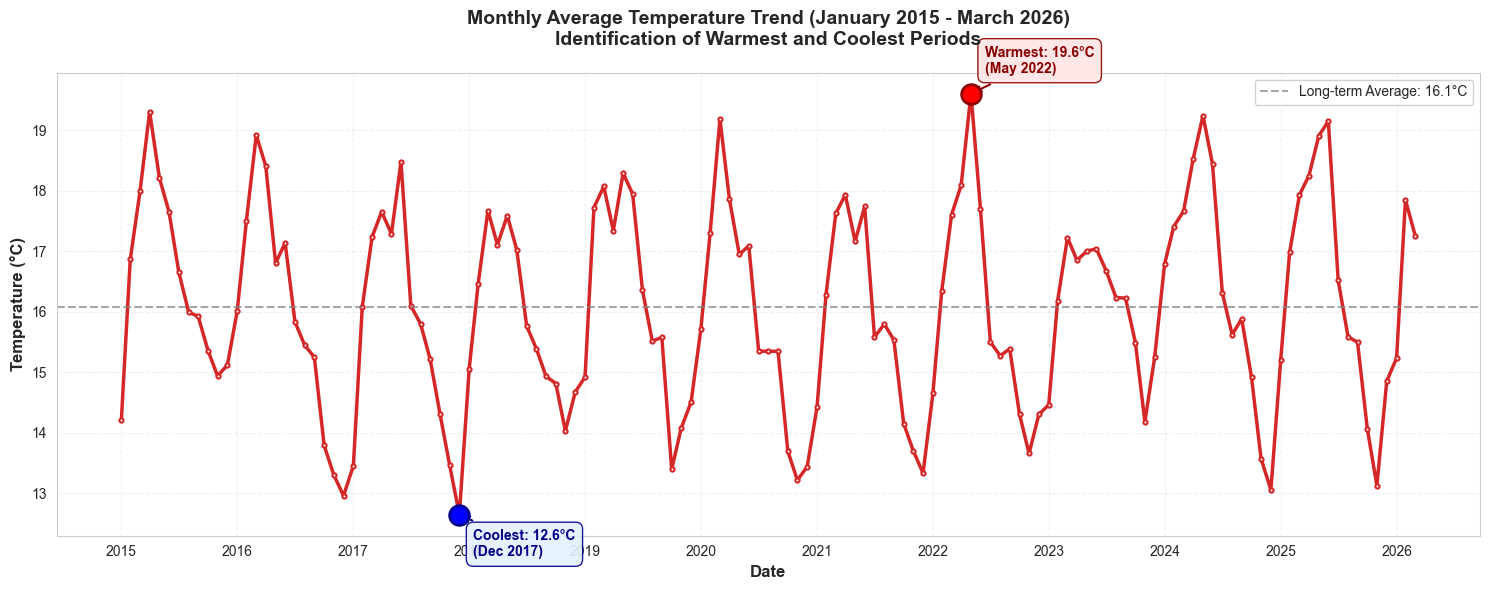

TEMPERATURE EXTREMES ANALYSIS
Data period: Jan 2015 - Mar 2026
★ Warmest Month: May 2022 - 19.6°C
★ Coolest Month: Dec 2017 - 12.6°C
📊 Temperature Range: 7.0°C
📈 Long-term Average: 16.1°C


In [15]:
# Prepare data
monthly_temp = df.resample("ME", on="Date")["T2M"].mean().reset_index()
monthly_temp['Month_Name'] = monthly_temp['Date'].dt.strftime('%b %Y')
monthly_temp['Year'] = monthly_temp['Date'].dt.year
monthly_temp['Month_Num'] = monthly_temp['Date'].dt.month

# Find warmest and coolest months
warmest_idx = monthly_temp['T2M'].idxmax()
coolest_idx = monthly_temp['T2M'].idxmin()
warmest_month = monthly_temp.loc[warmest_idx]
coolest_month = monthly_temp.loc[coolest_idx]

# Create the plot with cleaner line
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# plot
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 
         color='#d62728', linewidth=2.5, marker='o', 
         markersize=3, markerfacecolor='white', markeredgewidth=1.5,
         linestyle='-')

# Annotate warmest month
plt.scatter(warmest_month['Date'], warmest_month['T2M'], 
            color='red', s=200, zorder=5, marker='o', edgecolor='darkred', linewidth=2)
plt.annotate(f'Warmest: {warmest_month["T2M"]:.1f}°C\n({warmest_month["Month_Name"]})', 
             xy=(warmest_month['Date'], warmest_month['T2M']), 
             xytext=(10, 15), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe5e5', edgecolor='darkred', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

# Annotate coolest month
plt.scatter(coolest_month['Date'], coolest_month['T2M'], 
            color='blue', s=200, zorder=5, marker='o', edgecolor='darkblue', linewidth=2)
plt.annotate(f'Coolest: {coolest_month["T2M"]:.1f}°C\n({coolest_month["Month_Name"]})', 
             xy=(coolest_month['Date'], coolest_month['T2M']), 
             xytext=(10, -30), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkblue',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#e5f0ff', edgecolor='darkblue', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5))

# Add horizontal line for average temperature
avg_temp = monthly_temp['T2M'].mean()
plt.axhline(y=avg_temp, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, 
            label=f'Long-term Average: {avg_temp:.1f}°C')

# Customize the chart
plt.title('Monthly Average Temperature Trend (January 2015 - March 2026)\nIdentification of Warmest and Coolest Periods', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='semibold')
plt.ylabel('Temperature (°C)', fontsize=12, fontweight='semibold')
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')

# Improve x-axis labels - show every 12 months (yearly)
ax = plt.gca()
years = pd.date_range(start='2015-01-31', end='2026-03-31', freq='12ME')
ax.set_xticks(years)
ax.set_xticklabels([yr.strftime('%Y') for yr in years], rotation=0)

plt.tight_layout()
plt.show()

# Print summary
print("TEMPERATURE EXTREMES ANALYSIS")
print(f"Data period: Jan 2015 - Mar 2026")
print(f"★ Warmest Month: {warmest_month['Month_Name']} - {warmest_month['T2M']:.1f}°C")
print(f"★ Coolest Month: {coolest_month['Month_Name']} - {coolest_month['T2M']:.1f}°C")
print(f"📊 Temperature Range: {warmest_month['T2M'] - coolest_month['T2M']:.1f}°C")
print(f"📈 Long-term Average: {avg_temp:.1f}°C")

### Observation
1. **Bimodal Pattern (Two Peaks per Year)**
The temperature oscillates between **~12°C and ~17-19°C** in a clear pattern:
    - *Cooler periods:* ~12°C (appears multiple times per year)
    - *Warmer periods:* ~17-19°C


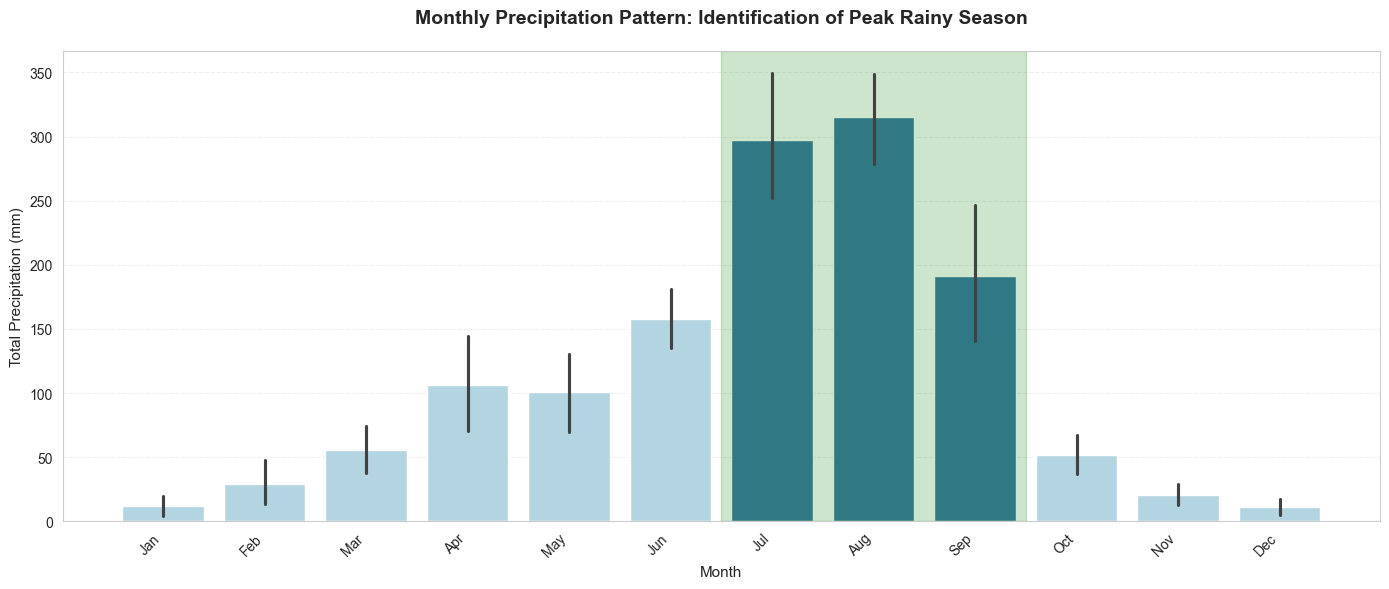


=== Peak Rainy Season Analysis ===
Peak months: 7-9
Total rain in peak season: 8844mm
Percentage of annual rain: 59.2%

=== Monthly Breakdown ===
Aug: 3466mm
Jul: 3271mm
Sep: 2107mm
Jun: 1736mm
Apr: 1170mm
May: 1105mm


In [16]:
# Prepare data
monthly_rain = df.resample("ME", on="Date")["PRECTOTCORR"].sum().reset_index()
monthly_rain['Month_Num'] = monthly_rain['Date'].dt.month
monthly_rain['Year'] = monthly_rain['Date'].dt.year
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Calculate average by month across years
monthly_avg = df.groupby(df['Date'].dt.month)['PRECTOTCORR'].sum()

# --- DYNAMIC PEAK SEASON IDENTIFICATION ---
# Find the 3 consecutive months with highest total rainfall
monthly_totals = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum()

best_total = 0
peak_start = 3  # default
peak_end = 5    # default

# Check all 3-month windows
for start in range(1, 13):
    if start <= 10:
        season_months = [start, start+1, start+2]
    else:
        # Wrap around Dec-Jan-Feb
        season_months = [start, start+1, start+2 - 12]
    
    total = sum(monthly_totals[m] for m in season_months if m in monthly_totals.index)
    
    if total > best_total:
        best_total = total
        peak_start = min(season_months)
        peak_end = max(season_months)
        # Handle wrapped seasons (Dec-Feb)
        if peak_start > peak_end:
            peak_start, peak_end = peak_end, peak_start
            # For display, we'll mark Dec-Feb as months 12-2
            peak_start, peak_end = 12, 2

# Create figure with professional styling
fig, ax = plt.subplots(figsize=(14, 6))

# Create color array based on dynamic peak season
# Handle wrapped season
if peak_start > peak_end: 
    peak_months = list(range(peak_start, 13)) + list(range(1, peak_end + 1))
else:
    peak_months = list(range(peak_start, peak_end + 1))

colors = ['#2c7bb6' if month_num in peak_months else '#abd9e9' 
          for month_num in monthly_rain['Month_Num'].unique()]

# Bar plot
bars = sns.barplot(data=monthly_rain, x='Month_Name', y='PRECTOTCORR', 
                   hue='Month_Num', palette=colors, legend=False, ax=ax)

# Annotate highest peak
max_idx = monthly_rain['PRECTOTCORR'].idxmax()
max_value = monthly_rain.loc[max_idx, 'PRECTOTCORR']
max_month = monthly_rain.loc[max_idx, 'Month_Name']

ax.annotate(f'Highest: {max_value:.0f}mm', 
            xy=(max_idx, max_value), xytext=(max_idx, max_value + 30),
            ha='center', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Format peak season label for display
if peak_start > peak_end:
    # Handle wrapped season (e.g., Dec-Feb)
    month_names = []
    for m in sorted(peak_months):
        month_names.append(monthly_rain[monthly_rain['Month_Num'] == m]['Month_Name'].iloc[0])
    season_label = f'Peak Rainy Season ({", ".join(month_names)})'
    
    dec_indices = monthly_rain[monthly_rain['Month_Num'] == 12].index
    jan_feb_indices = monthly_rain[monthly_rain['Month_Num'].isin([1, 2])].index
    
    if len(dec_indices) > 0:
        ax.axvspan(dec_indices[0] - 0.5, dec_indices[-1] + 0.5, alpha=0.2, color='green')
    if len(jan_feb_indices) > 0:
        ax.axvspan(jan_feb_indices[0] - 0.5, jan_feb_indices[-1] + 0.5, alpha=0.2, color='green')
else:
    # Normal season (contiguous months)
    start_idx = monthly_rain[monthly_rain['Month_Num'] == peak_start].index[0]
    end_idx = monthly_rain[monthly_rain['Month_Num'] == peak_end].index[0]
    season_label = f'Peak Rainy Season (Month {peak_start}-{peak_end})'
    ax.axvspan(start_idx - 0.5, end_idx + 0.5, alpha=0.2, color='green', label=season_label)

# Add legend for shaded area if not already added
handles, labels = ax.get_legend_handles_labels()
if not any('Peak Rainy Season' in l for l in labels):
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='green', alpha=0.2, label=season_label)], 
              loc='upper right', framealpha=0.9)

# Styling
ax.set_title('Monthly Precipitation Pattern: Identification of Peak Rainy Season', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Precipitation (mm)', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Rotate x-labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# summary
print("\n=== Peak Rainy Season Analysis ===")
print(f"Peak months: {peak_start}-{peak_end}" if peak_start <= peak_end else f"Peak months: {peak_start}, {peak_end} (wrapped)")
print(f"Total rain in peak season: {best_total:.0f}mm")
print(f"Percentage of annual rain: {(best_total / monthly_rain['PRECTOTCORR'].sum() * 100):.1f}%")

# Additional insights
print("\n=== Monthly Breakdown ===")
monthly_breakdown = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum().sort_values(ascending=False)
for month_num, total in monthly_breakdown.head(6).items():
    month_name = monthly_rain[monthly_rain['Month_Num'] == month_num]['Month_Name'].iloc[0]
    print(f"{month_name}: {total:.0f}mm")

### Observation

**Trends:**

1. **Unimodal peak** - Rainfall rises steadily from Jan (15mm) to a single sharp peak in **August (315mm)**, then declines

2. **Clear wet season** - June through September (160→295→315→190mm)

3. **Clear dry season** - October through February (50→25→10→15→30mm)